# GBM Fitting and Simulation

Despite concluding in [notebook 2](02_return_distribution_analysis.ipynb) that the assumptions for GBM do not apply for our log returns data, there is still value in fitting the model and using it to simulate. In fact, it could be percieved as even more useful to do this, since we will be able to quantify the effect of our invalid assumptions on the predictive cabaility of the GBM model. 

In this notebook, we will be fitting the GBM model to our data, and testing it on out-of-sample data by simulating ahead and comparing to the real world outcomes. 

In [1]:
from datetime import datetime, timedelta

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:
df = pd.read_csv("../data/pg_daily.csv", index_col="date")

## GBM Parameter Estimation

There are two parameters to estimate for GBM: the drift, $\mu$, and the volatility, $\sigma$. These two parameters fully describe our model.

The best estimate for $\sigma$ is simply the sample standard deviation of the log returns. For $\mu$, matters are slightly less direct: the sample mean of log returns is actually an estimate of $\mu - \tfrac{\hat{\sigma}^2}{2}$, not of $\mu$ due to volatility drag. So to recover $\hat{\mu}$, we take the sample mean and add back $\tfrac{\hat{\sigma}^2}{2}$. In practice, our model contains the log-return drift term itself, $\hat{\mu} - \tfrac{\hat{\sigma}^2}{2}$, so we use the sample mean directly rather than reconstructing it via $\hat{\mu}$.

Note that here we will create a dedicated "training set" that we will use to fit our parameters.

In [3]:
TRAIN_CUTOFF = "2024-12-31"

train = df.loc[:TRAIN_CUTOFF, "log_return"].dropna()

s0 = df.loc[TRAIN_CUTOFF, "close"]

In [4]:
sigma_hat = train.std()
drift_term = train.mean() # drift of ln(S_t), i.e. mu_hat - sigma_hat**2/2

## Simulation

Now that we have our parameters estimated we can simulate our asset's price daily over a simulation period immediately after our training period. We do this by using the theoretical "true" formula for $S_t$, the close price on day $t$ of our simulation window:

$$S_t = S_0 \exp((\mu - \tfrac{\sigma^2}{2})t + \sigma W_t)$$

where $S_0$ is the closing price on the last day of the training set, and $W_t$ is a standard Brownian motion. In practice, we will replace the volatility $\sigma$ with the sample standard deviation that we have already calculated, and replace the drift term $\mu - \tfrac{\sigma^2}{2}$ with its estimate that we have already calculated - the sample mean.

In [5]:
SIM_START =  (datetime.strptime(TRAIN_CUTOFF, "%Y-%m-%d") + timedelta(days=1)).strftime("%Y-%m-%d")
SIM_END = (datetime.strptime(TRAIN_CUTOFF, "%Y-%m-%d") + timedelta(days=365)).strftime("%Y-%m-%d")

sim_df = df.loc[SIM_START:SIM_END]
n_sim = len(sim_df)


In [6]:
PRE_SIM_START =  (datetime.strptime(TRAIN_CUTOFF, "%Y-%m-%d") + timedelta(days=-50)).strftime("%Y-%m-%d") # last 50 days of training data for visualisation purposes
pre_sim_df = df.loc[PRE_SIM_START:TRAIN_CUTOFF]

In [7]:
def simulate(seed = None):
    t = np.arange(1, n_sim + 1)
    rng = np.random.default_rng(seed=seed)
    e_t = rng.normal(loc=0, scale=1, size=n_sim) 
    w_t = np.cumsum(e_t) 
    s_t = s0 * np.exp(drift_term * t + sigma_hat * w_t)      
    return s_t                              

In [8]:
def multiple_simulation(n_sims: int, return_sims: bool = True, plot: bool = True, seed: int = None, opaque_plot: bool = False):
    pre_sim_array = np.array(pre_sim_df["close"])
    sim_actual_array = np.concatenate([pre_sim_array, np.array(sim_df["close"])])
    date_array = np.concatenate([np.array(pre_sim_df.index), np.array(sim_df.index)])

    rng = np.random.default_rng(42)
    seeds = rng.integers(low=1, high=10e10, size=n_sims)
    sims = [simulate(seed=s) for s in seeds]

    if plot:
        plt.figure(figsize=(12, 6))

        plt.plot(date_array, sim_actual_array, label="Actual", color="blue", zorder=10)

        max_price = max(sim_actual_array)
        min_price = min(sim_actual_array)

        for i, sim_array in enumerate(sims):
            full_sim_array = np.concatenate([pre_sim_array, sim_array])

            opacity = 0.3 if opaque_plot else 1
            color = "grey" if opaque_plot else "orange"
            label = "Simulated" if i == 0 else None
            plt.plot(date_array, full_sim_array, label=label, color=color, alpha=opacity)

            if min(sim_array) < min_price:
                min_price = min(sim_array)

            if max(sim_array) > max_price:
                max_price = max(sim_array)

        ax = plt.gca()
        ax.xaxis.set_major_locator(mdates.AutoDateLocator())
        plt.gcf().autofmt_xdate()


        text_ypos = min_price + (max_price - min_price) * 0.05
        plt.text(38, text_ypos, "Simulation\nstart", color="red")
        plt.axvline(x=TRAIN_CUTOFF, color="red", linestyle="--")

        plt.ylim(min_price, max_price)

        plt.title(f"Comparing Close Price Actual vs GBM Simulation ($n={n_sims}$)")
        plt.xlabel("Date")
        plt.ylabel("Close Price (USD)")
        plt.legend()
        plt.show()
    
    if return_sims:
        return sims

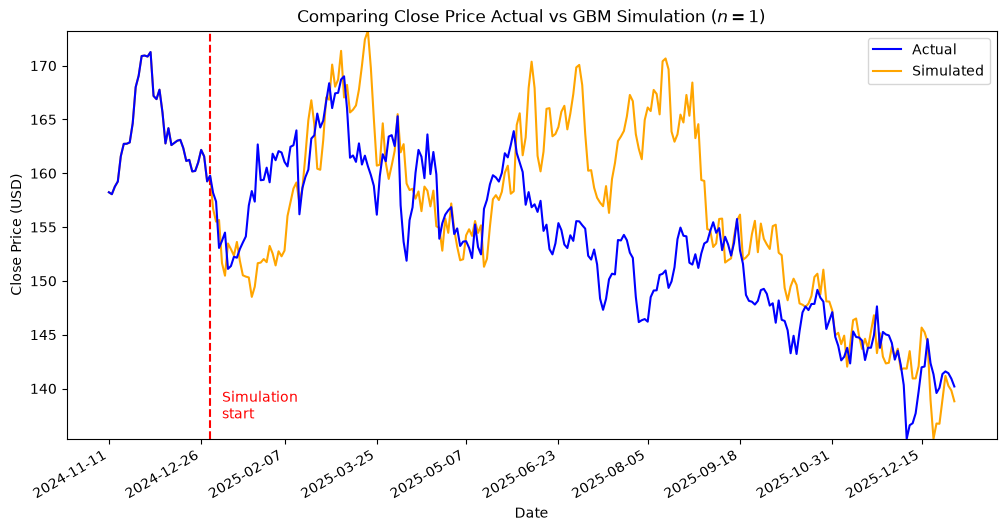

In [9]:
multiple_simulation(1, seed=1, return_sims=False)

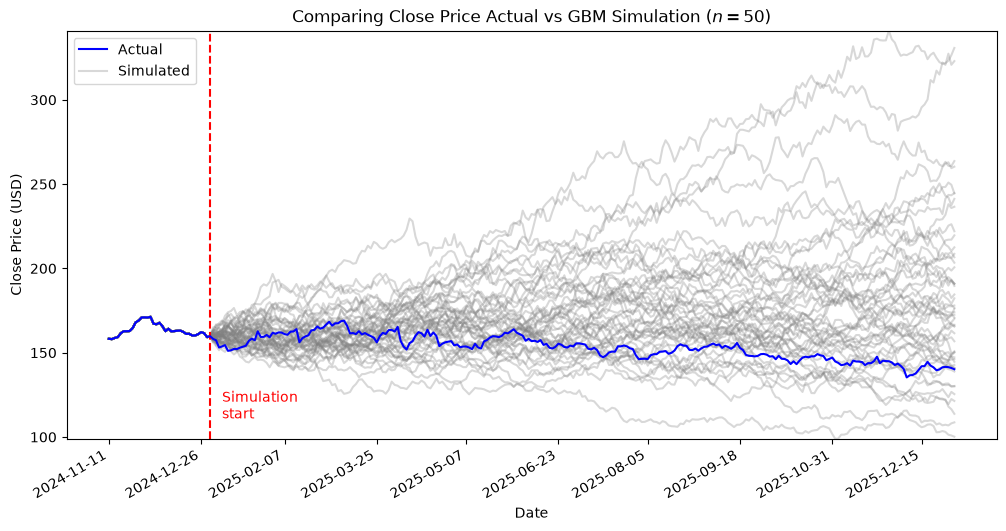

In [10]:
multiple_simulation(50, seed=1, return_sims=False, opaque_plot=True)

In [11]:
sims = multiple_simulation(10_000, seed=1, plot=False)

In [12]:
sim_terminal_prices = [s[-1] for s in sims]
actual_terminal_price = sim_df.loc[SIM_END, "close"]

In [13]:
print(f"The actual closing price on {SIM_END} was {actual_terminal_price:.2f} USD")
print(f"The mean simulated terminal price was {np.mean(sim_terminal_prices):.2f} USD")

The actual closing price on 2025-12-31 was 140.19 USD
The mean simulated terminal price was 181.53 USD


In [14]:
pct = (sim_terminal_prices < actual_terminal_price).mean() * 100
print(f"The actual closing price on {SIM_END} fell at the {pct:.0f}th percentile of simulated terminal prices.")

The actual closing price on 2025-12-31 fell at the 14th percentile of simulated terminal prices.


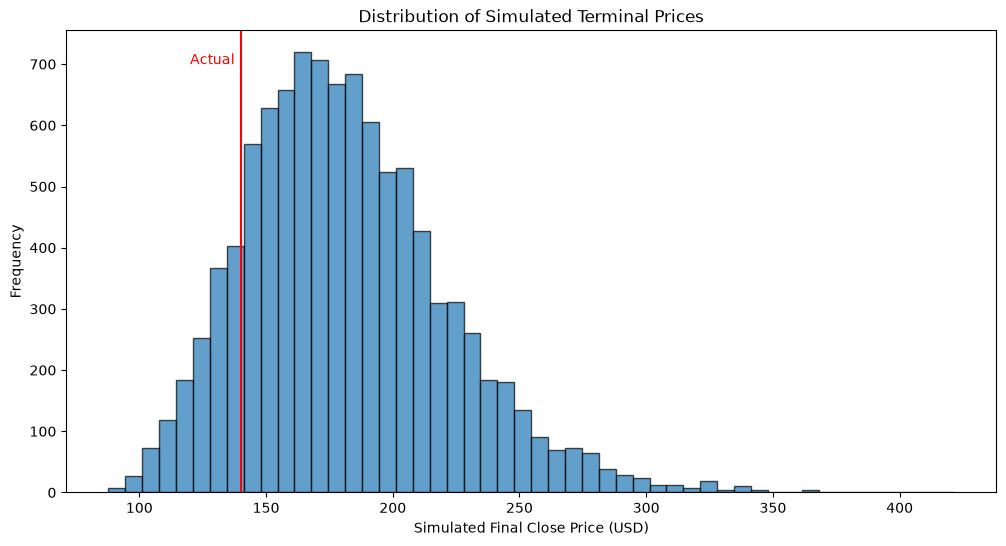

In [15]:
plt.figure(figsize=(12, 6))

plt.hist(sim_terminal_prices, bins=50, edgecolor="black", alpha=0.7)
plt.axvline(x=actual_terminal_price, color="red")
plt.text(120, 700, "Actual", color="red")


plt.xlabel("Simulated Final Close Price (USD)")
plt.ylabel("Frequency")
plt.title("Distribution of Simulated Terminal Prices")
plt.show()

## Evaluation

#### Log Returns Distribution Comparison

In [16]:
log_returns = []
for sim in sims:
    sim_log_returns = np.diff(np.log(sim))
    log_returns.extend(sim_log_returns)

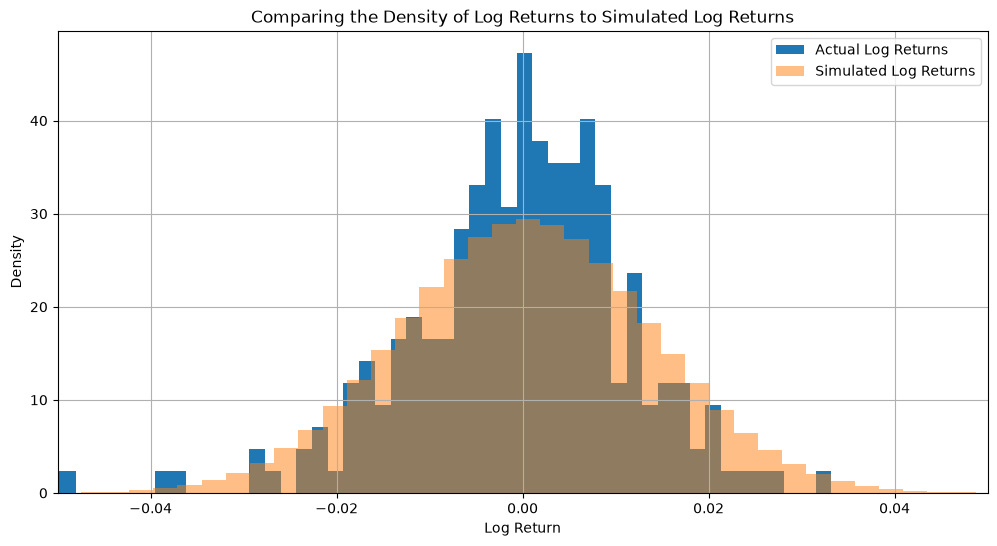

In [17]:
plt.figure(figsize=(12, 6))

sim_df['log_return'].hist(bins=50, density=True, label="Actual Log Returns")
plt.hist(log_returns, bins=50, density=True, label="Simulated Log Returns", alpha=0.5)

plt.xlim(-0.05, 0.05)
plt.title("Comparing the Density of Log Returns to Simulated Log Returns")
plt.xlabel("Log Return")
plt.ylabel("Density")
plt.legend()
plt.show()

In [18]:
pct_returns = []
for sim in sims:
    sim_pct_returns = np.diff(sim) / sim[:-1]
    pct_returns.extend(sim_pct_returns)

In [19]:
def extreme_value_prop(data, p, ):
    count = 0
    for d in data:
        if abs(d) > p:
            count += 1
    return count / len(data)

In [20]:
pct1 = extreme_value_prop(sim_df["pct_return"], 0.01) * 100
pct2 = extreme_value_prop(sim_df["pct_return"], 0.02) * 100
pct3 = extreme_value_prop(sim_df["pct_return"], 0.03) * 100
pct1_sim = extreme_value_prop(pct_returns, 0.01) * 100
pct2_sim = extreme_value_prop(pct_returns, 0.02) * 100
pct3_sim = extreme_value_prop(pct_returns, 0.03) * 100

In [21]:
print(f"{pct1_sim:.2f}% of simulated percentage returns exceeded ±1% vs {pct1:.2f}% actual.") 
print(f"{pct2_sim:.2f}% of simulated percentage returns exceeded ±2% vs {pct2:.2f}% actual.") 
print(f"{pct3_sim:.2f}% of simulated percentage returns exceeded ±3% vs {pct3:.2f}% actual.") 

46.06% of simulated percentage returns exceeded ±1% vs 34.00% actual.
14.02% of simulated percentage returns exceeded ±2% vs 8.80% actual.
2.70% of simulated percentage returns exceeded ±3% vs 2.00% actual.


#### Volatility Comparison

In [39]:
sim_sds = []
for sim in sims:
    sd = np.std(np.diff(np.log(sim)))
    sim_sds.append(sd)

actual_sd = np.std(sim_df["log_return"])

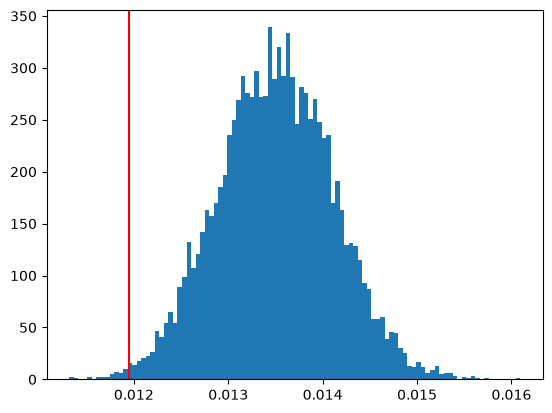

In [40]:
plt.hist(sim_sds, bins=100)
plt.axvline(x=actual_sd, color="red")
plt.show()

In [47]:
(sim_sds < actual_sd).mean()*100

np.float64(0.44999999999999996)

In [43]:
vol_pct = (sim_sds < actual_sd).mean()*100
print(f"The actual sample SD fell at the {vol_pct:.2f} percentile.")

The actual sample variance fell at the 0.45 percentile.


## Conclusion